<a href="https://colab.research.google.com/github/junseok-jay/2026-1_CV/blob/main/HW%233.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from torch.utils.data import TensorDataset, DataLoader

def load_digits_dataset(batch_size=64):
    digits = load_digits()

    X = digits.data
    y = digits.target

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=batch_size,
        shuffle=False
    )

    input_size = 64
    num_classes = 10

    return train_loader, test_loader, input_size, num_classes

In [4]:
train_loader, test_loader, input_size, num_classes = load_digits_dataset(batch_size=64)

print("input_size:", input_size)
print("num_classes:", num_classes)

input_size: 64
num_classes: 10


In [5]:
from torchvision import datasets, transforms

def load_fashion_mnist_dataset(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    input_size = 784
    num_classes = 10

    return train_loader, test_loader, input_size, num_classes

In [6]:
import torch.nn as nn


class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [7]:
def evaluate(model, test_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc

In [8]:
def train_model(
    model,
    train_loader,
    test_loader,
    loss_type,
    lr=0.001,
    epochs=30
):
    model = model.to(device)

    if loss_type == "cross_entropy":
        loss_fn = nn.CrossEntropyLoss()

    elif loss_type == "mse":
        loss_fn = nn.MSELoss()

    else:
        raise ValueError("loss_type은 cross_entropy 또는 mse만 가능합니다.")

    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "loss": [],
        "train_acc": [],
        "test_acc": [],
        "grad_norm": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        correct = 0
        total = 0
        total_grad_norm = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(X)

            if loss_type == "cross_entropy":
                loss = loss_fn(outputs, y)

            elif loss_type == "mse":
                probs = torch.softmax(outputs, dim=1)
                y_onehot = F.one_hot(y, num_classes=outputs.shape[1]).float()
                loss = loss_fn(probs, y_onehot)

            loss.backward()

            grad_norm = 0
            for param in model.parameters():
                if param.grad is not None:
                    grad_norm += param.grad.norm(2).item()

            total_grad_norm += grad_norm

            optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        avg_loss = total_loss / len(train_loader)
        train_acc = correct / total
        test_acc = evaluate(model, test_loader)
        avg_grad_norm = total_grad_norm / len(train_loader)

        history["loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["grad_norm"].append(avg_grad_norm)

        print(
            f"[{loss_type}] Epoch {epoch+1}/{epochs} | "
            f"Loss: {avg_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Acc: {test_acc:.4f} | "
            f"Grad Norm: {avg_grad_norm:.4f}"
        )

    return model, history

In [9]:
def run_experiment_A(
    dataset_name,
    train_loader,
    test_loader,
    input_size,
    num_classes,
    epochs
):
    print("=" * 70)
    print(f"Experiment A: {dataset_name}")
    print("=" * 70)

    set_seed(42)
    model_ce = MLP(input_size, num_classes)

    model_ce, hist_ce = train_model(
        model=model_ce,
        train_loader=train_loader,
        test_loader=test_loader,
        loss_type="cross_entropy",
        lr=0.001,
        epochs=epochs
    )

    set_seed(42)
    model_mse = MLP(input_size, num_classes)

    model_mse, hist_mse = train_model(
        model=model_mse,
        train_loader=train_loader,
        test_loader=test_loader,
        loss_type="mse",
        lr=0.001,
        epochs=epochs
    )

    return {
        "dataset": dataset_name,
        "ce_history": hist_ce,
        "mse_history": hist_mse
    }

In [10]:
digits_train_loader, digits_test_loader, digits_input_size, digits_num_classes = load_digits_dataset()

digits_result = run_experiment_A(
    dataset_name="Digits",
    train_loader=digits_train_loader,
    test_loader=digits_test_loader,
    input_size=digits_input_size,
    num_classes=digits_num_classes,
    epochs=50
)

Experiment A: Digits
[cross_entropy] Epoch 1/50 | Loss: 1.7341 | Train Acc: 0.6500 | Test Acc: 0.8000 | Grad Norm: 1.5806
[cross_entropy] Epoch 2/50 | Loss: 0.6345 | Train Acc: 0.8720 | Test Acc: 0.9139 | Grad Norm: 1.4892
[cross_entropy] Epoch 3/50 | Loss: 0.2412 | Train Acc: 0.9429 | Test Acc: 0.9472 | Grad Norm: 1.2146
[cross_entropy] Epoch 4/50 | Loss: 0.1285 | Train Acc: 0.9701 | Test Acc: 0.9694 | Grad Norm: 0.9315
[cross_entropy] Epoch 5/50 | Loss: 0.0802 | Train Acc: 0.9875 | Test Acc: 0.9639 | Grad Norm: 0.7528
[cross_entropy] Epoch 6/50 | Loss: 0.0547 | Train Acc: 0.9930 | Test Acc: 0.9722 | Grad Norm: 0.6119
[cross_entropy] Epoch 7/50 | Loss: 0.0432 | Train Acc: 0.9958 | Test Acc: 0.9694 | Grad Norm: 0.5638
[cross_entropy] Epoch 8/50 | Loss: 0.0295 | Train Acc: 0.9979 | Test Acc: 0.9750 | Grad Norm: 0.4213
[cross_entropy] Epoch 9/50 | Loss: 0.0245 | Train Acc: 0.9972 | Test Acc: 0.9667 | Grad Norm: 0.4026
[cross_entropy] Epoch 10/50 | Loss: 0.0169 | Train Acc: 0.9986 | Test 

In [11]:
fashion_train_loader, fashion_test_loader, fashion_input_size, fashion_num_classes = load_fashion_mnist_dataset()

fashion_result = run_experiment_A(
    dataset_name="Fashion-MNIST",
    train_loader=fashion_train_loader,
    test_loader=fashion_test_loader,
    input_size=fashion_input_size,
    num_classes=fashion_num_classes,
    epochs=30
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.37MB/s]


Experiment A: Fashion-MNIST
[cross_entropy] Epoch 1/30 | Loss: 0.5235 | Train Acc: 0.8110 | Test Acc: 0.8390 | Grad Norm: 2.9190
[cross_entropy] Epoch 2/30 | Loss: 0.3715 | Train Acc: 0.8635 | Test Acc: 0.8538 | Grad Norm: 2.1514
[cross_entropy] Epoch 3/30 | Loss: 0.3359 | Train Acc: 0.8768 | Test Acc: 0.8692 | Grad Norm: 1.9723
[cross_entropy] Epoch 4/30 | Loss: 0.3083 | Train Acc: 0.8854 | Test Acc: 0.8707 | Grad Norm: 1.8853
[cross_entropy] Epoch 5/30 | Loss: 0.2889 | Train Acc: 0.8936 | Test Acc: 0.8758 | Grad Norm: 1.8168
[cross_entropy] Epoch 6/30 | Loss: 0.2724 | Train Acc: 0.8988 | Test Acc: 0.8828 | Grad Norm: 1.7582
[cross_entropy] Epoch 7/30 | Loss: 0.2604 | Train Acc: 0.9027 | Test Acc: 0.8792 | Grad Norm: 1.7569
[cross_entropy] Epoch 8/30 | Loss: 0.2497 | Train Acc: 0.9066 | Test Acc: 0.8818 | Grad Norm: 1.7292
[cross_entropy] Epoch 9/30 | Loss: 0.2348 | Train Acc: 0.9125 | Test Acc: 0.8851 | Grad Norm: 1.6708
[cross_entropy] Epoch 10/30 | Loss: 0.2237 | Train Acc: 0.9163 

In [12]:
def plot_experiment_A(result):
    dataset = result["dataset"]
    ce = result["ce_history"]
    mse = result["mse_history"]

    plt.figure(figsize=(8, 5))
    plt.plot(ce["loss"], label="CrossEntropy")
    plt.plot(mse["loss"], label="MSE with Softmax")
    plt.title(f"{dataset} - Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(ce["test_acc"], label="CrossEntropy")
    plt.plot(mse["test_acc"], label="MSE with Softmax")
    plt.title(f"{dataset} - Accuracy vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(ce["grad_norm"], label="CrossEntropy")
    plt.plot(mse["grad_norm"], label="MSE with Softmax")
    plt.title(f"{dataset} - Gradient Norm vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm")
    plt.legend()
    plt.grid(True)
    plt.show()

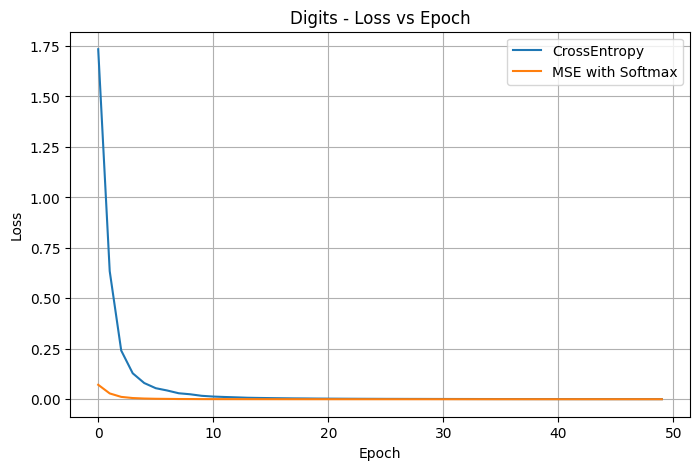

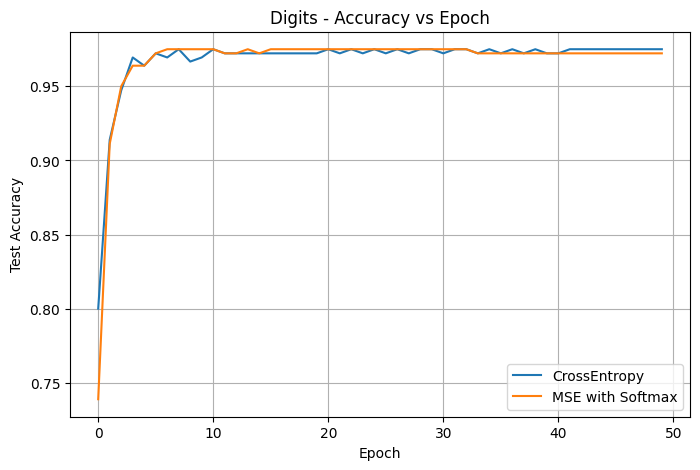

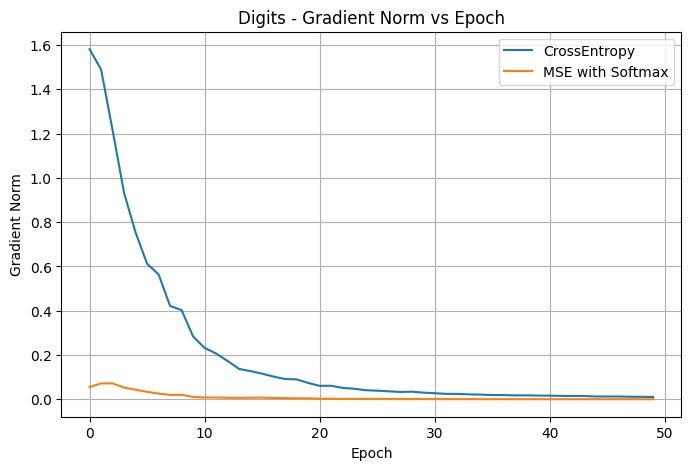

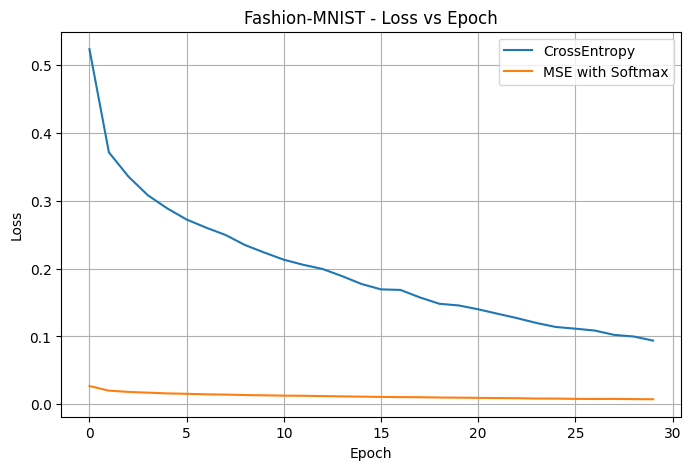

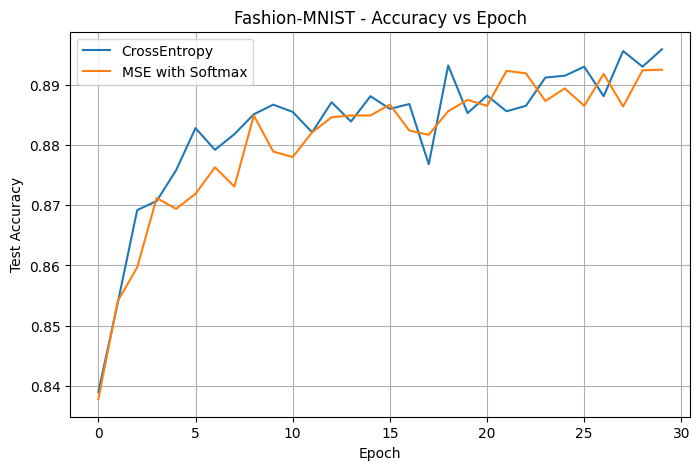

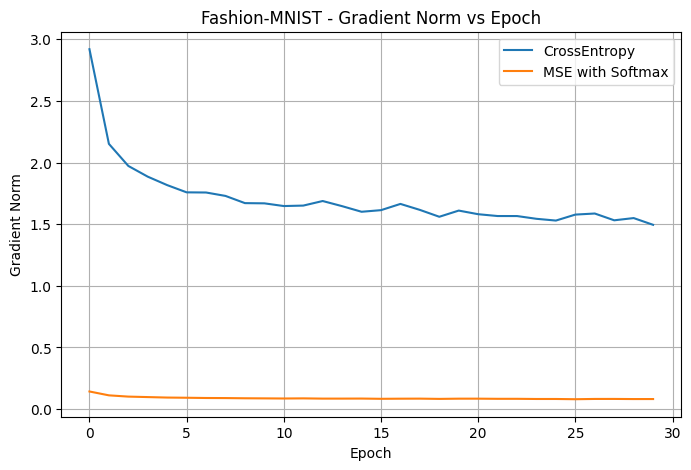

In [13]:
plot_experiment_A(digits_result)
plot_experiment_A(fashion_result)

In [14]:
def find_convergence_epoch(acc_list, threshold):
    for i, acc in enumerate(acc_list):
        if acc >= threshold:
            return i + 1
    return None

In [15]:
def make_result_table(result, threshold):
    dataset = result["dataset"]
    ce = result["ce_history"]
    mse = result["mse_history"]

    table = pd.DataFrame({
        "Dataset": [
            dataset,
            dataset
        ],
        "Loss Function": [
            "CrossEntropy",
            "MSE with Softmax"
        ],
        "Final Test Accuracy": [
            ce["test_acc"][-1],
            mse["test_acc"][-1]
        ],
        "Minimum Loss": [
            min(ce["loss"]),
            min(mse["loss"])
        ],
        "Final Gradient Norm": [
            ce["grad_norm"][-1],
            mse["grad_norm"][-1]
        ],
        "Convergence Epoch": [
            find_convergence_epoch(ce["test_acc"], threshold),
            find_convergence_epoch(mse["test_acc"], threshold)
        ]
    })

    return table

In [16]:
digits_table = make_result_table(digits_result, threshold=0.95)
fashion_table = make_result_table(fashion_result, threshold=0.85)

experiment_A_table = pd.concat(
    [digits_table, fashion_table],
    ignore_index=True
)

experiment_A_table

,Dataset,Loss Function,Final Test Accuracy,Minimum Loss,Final Gradient Norm,Convergence Epoch
0,Digits,CrossEntropy,0.975000,0.000418,0.010451,4
1,Digits,MSE with Softmax,0.972222,0.000008,0.000328,3
2,Fashion-MNIST,CrossEntropy,0.895900,0.093845,1.494831,2
3,Fashion-MNIST,MSE with Softmax,0.892500,0.007395,0.081796,2


In [17]:
def plot_experiment_A(result):
    dataset = result["dataset"]
    ce = result["ce_history"]
    mse = result["mse_history"]

    # Loss 그래프
    plt.figure(figsize=(8, 5))
    plt.plot(ce["loss"], label="CrossEntropy")
    plt.plot(mse["loss"], label="MSE with Softmax")
    plt.title(f"{dataset} - Loss / Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy 그래프
    plt.figure(figsize=(8, 5))
    plt.plot(ce["test_acc"], label="CrossEntropy")
    plt.plot(mse["test_acc"], label="MSE with Softmax")
    plt.title(f"{dataset} - Accuracy / Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gradient Norm 그래프
    plt.figure(figsize=(8, 5))
    plt.plot(ce["grad_norm"], label="CrossEntropy")
    plt.plot(mse["grad_norm"], label="MSE with Softmax")
    plt.title(f"{dataset} - Gradient Norm / Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm")
    plt.legend()
    plt.grid(True)
    plt.show()

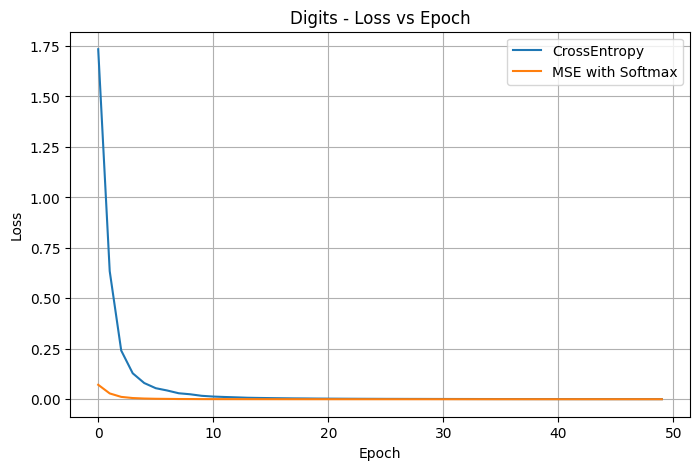

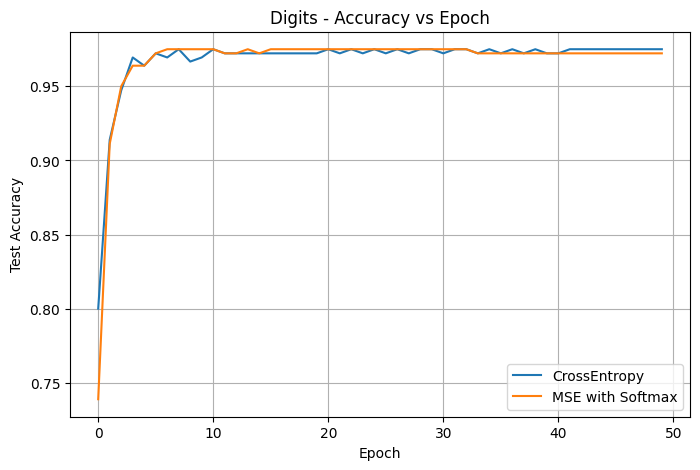

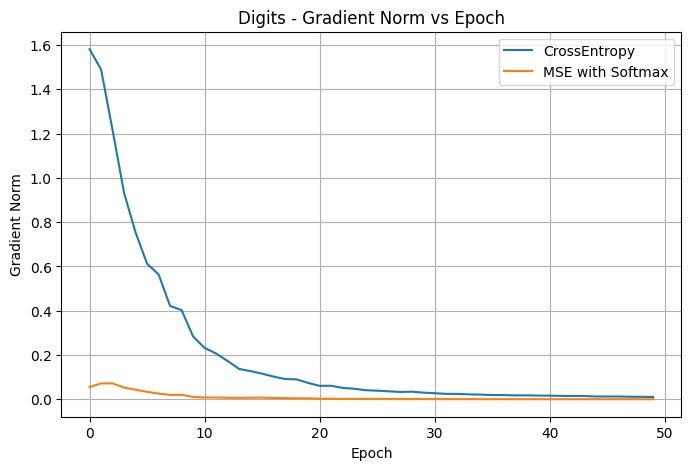

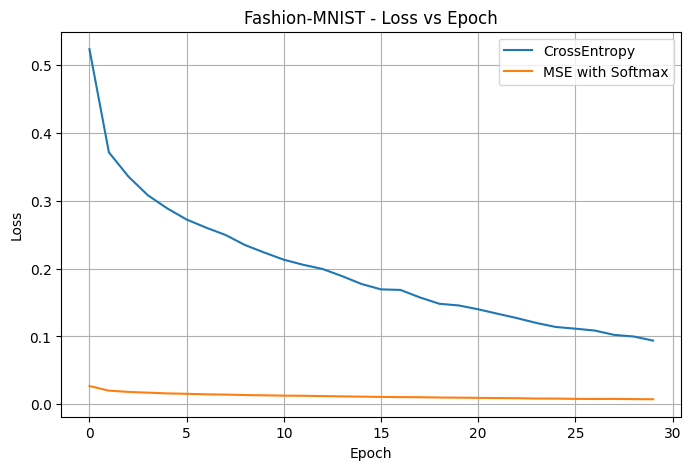

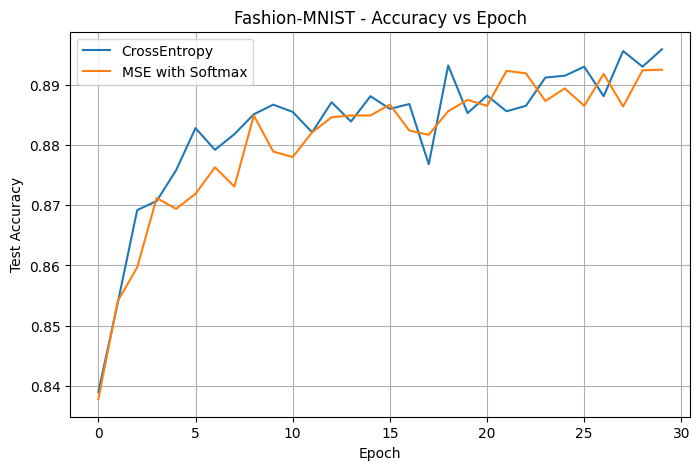

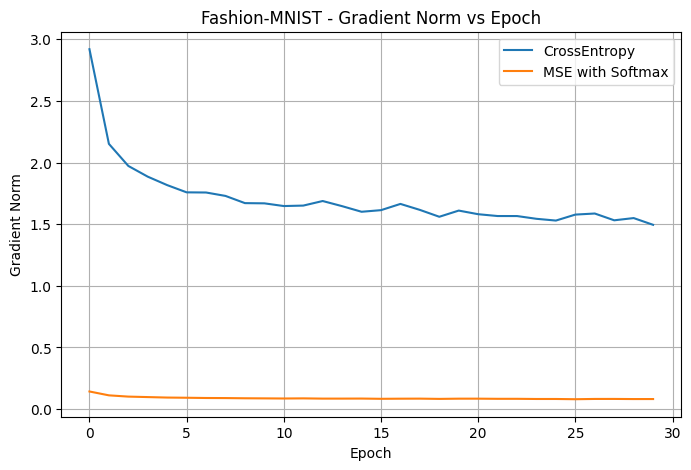

In [18]:
plot_experiment_A(digits_result)

In [ ]:
plot_experiment_A(fashion_result)

Experiment A: Digits
[cross_entropy] Epoch 1/50 | Loss: 1.7341 | Train Acc: 0.6500 | Test Acc: 0.8000 | Grad Norm: 1.5806
[cross_entropy] Epoch 2/50 | Loss: 0.6345 | Train Acc: 0.8720 | Test Acc: 0.9139 | Grad Norm: 1.4892
[cross_entropy] Epoch 3/50 | Loss: 0.2412 | Train Acc: 0.9429 | Test Acc: 0.9472 | Grad Norm: 1.2146
[cross_entropy] Epoch 4/50 | Loss: 0.1285 | Train Acc: 0.9701 | Test Acc: 0.9694 | Grad Norm: 0.9315
[cross_entropy] Epoch 5/50 | Loss: 0.0802 | Train Acc: 0.9875 | Test Acc: 0.9639 | Grad Norm: 0.7528
[cross_entropy] Epoch 6/50 | Loss: 0.0547 | Train Acc: 0.9930 | Test Acc: 0.9722 | Grad Norm: 0.6119
[cross_entropy] Epoch 7/50 | Loss: 0.0432 | Train Acc: 0.9958 | Test Acc: 0.9694 | Grad Norm: 0.5638
[cross_entropy] Epoch 8/50 | Loss: 0.0295 | Train Acc: 0.9979 | Test Acc: 0.9750 | Grad Norm: 0.4213
[cross_entropy] Epoch 9/50 | Loss: 0.0245 | Train Acc: 0.9972 | Test Acc: 0.9667 | Grad Norm: 0.4026
[cross_entropy] Epoch 10/50 | Loss: 0.0169 | Train Acc: 0.9986 | Test 

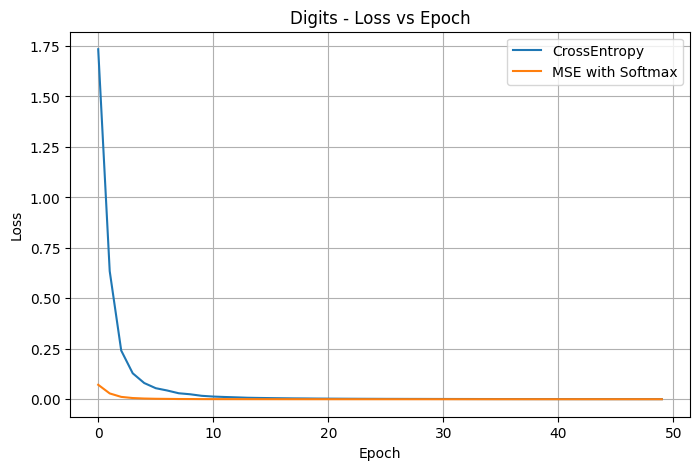

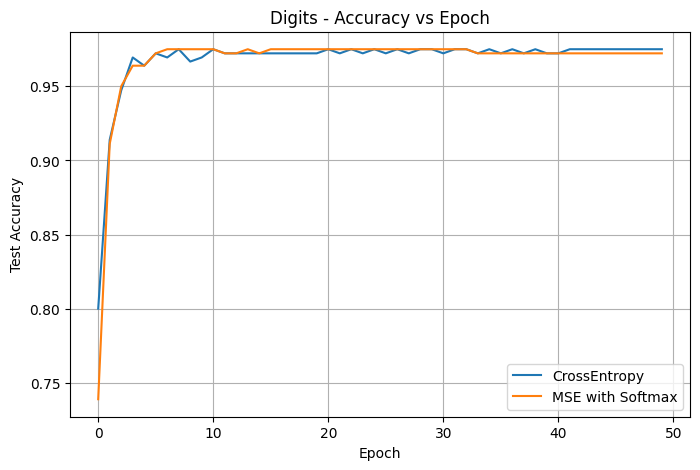

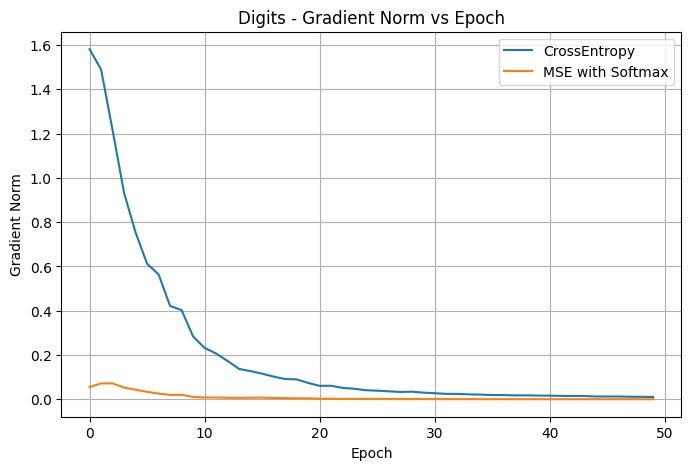

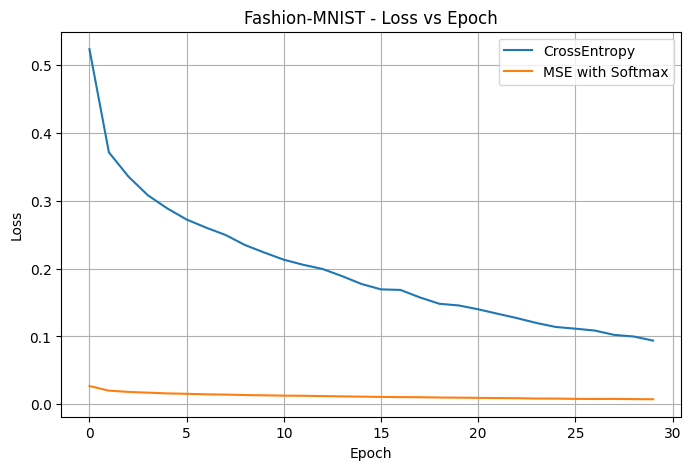

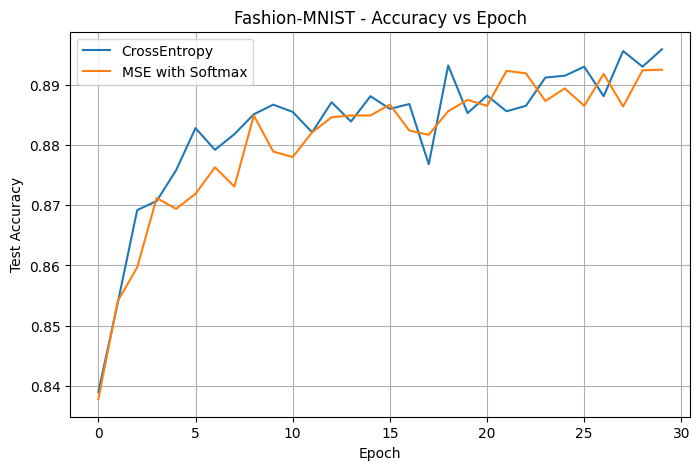

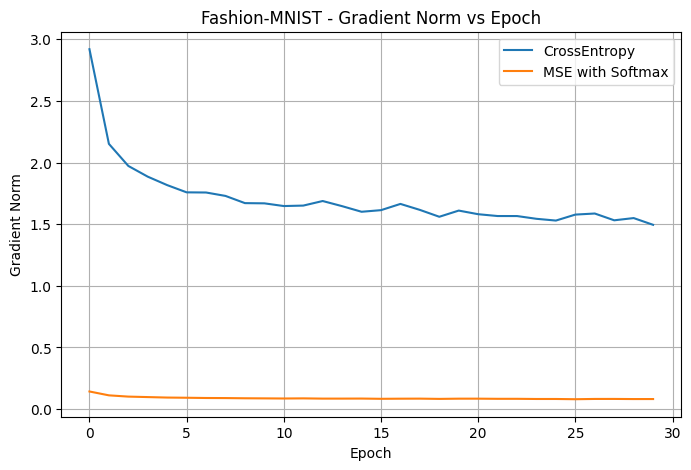

,Dataset,Loss Function,Final Test Accuracy,Minimum Loss,Final Gradient Norm,Convergence Epoch
0,Digits,CrossEntropy,0.975000,0.000418,0.010451,4
1,Digits,MSE with Softmax,0.972222,0.000008,0.000328,3
2,Fashion-MNIST,CrossEntropy,0.895900,0.093845,1.494831,2
3,Fashion-MNIST,MSE with Softmax,0.892500,0.007395,0.081796,2


In [19]:
# 1. Digits 실험
digits_train_loader, digits_test_loader, digits_input_size, digits_num_classes = load_digits_dataset()

digits_result = run_experiment_A(
    dataset_name="Digits",
    train_loader=digits_train_loader,
    test_loader=digits_test_loader,
    input_size=digits_input_size,
    num_classes=digits_num_classes,
    epochs=50
)

# 2. Fashion-MNIST 실험
fashion_train_loader, fashion_test_loader, fashion_input_size, fashion_num_classes = load_fashion_mnist_dataset()

fashion_result = run_experiment_A(
    dataset_name="Fashion-MNIST",
    train_loader=fashion_train_loader,
    test_loader=fashion_test_loader,
    input_size=fashion_input_size,
    num_classes=fashion_num_classes,
    epochs=30
)

# 3. 그래프 표시
plot_experiment_A(digits_result)
plot_experiment_A(fashion_result)

# 4. 정량 비교표 표시
digits_table = make_result_table(digits_result, threshold=0.95)
fashion_table = make_result_table(fashion_result, threshold=0.85)

experiment_A_table = pd.concat(
    [digits_table, fashion_table],
    ignore_index=True
)

experiment_A_table